# 05 - Decision Economics

A review policy is selected on the policy block and frozen before final test evaluation. Capacity is enforced within elapsed-hour queue windows.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
ART = ROOT / 'artifacts'
FIG = ROOT / 'reports' / 'figures'
pd.set_option('display.max_columns', 100)


In [2]:
policy = pd.read_csv(ART / 'policy_selection_results.csv')
policy

Out[0]: 
                     policy  transactions  alerts  alert_rate  \
0              f1_threshold         28374      30    0.001057   
1                 fixed_0.5         28374      31    0.001093   
2  avoidable_value_capacity         28374      56    0.001974   
3      probability_capacity         28374     105    0.003701   
4    expected_loss_capacity         28374     105    0.003701   
5               approve_all         28374       0    0.000000   

   true_fraud_alerts  false_positive_alerts  precision  fraud_count_recall  \
0                 30                      0   1.000000            0.731707   
1                 30                      1   0.967742            0.731707   
2                 30                     26   0.535714            0.731707   
3                 35                     70   0.333333            0.853659   
4                 28                     77   0.266667            0.682927   
5                  0                      0   0.000000            0

In [3]:
test = pd.read_csv(ART / 'final_test_policy_results.csv')
test

Out[0]: 
                     policy  transactions  alerts  alert_rate  \
0    expected_loss_capacity         42557     126    0.002961   
1  avoidable_value_capacity         42557      83    0.001950   
2                 fixed_0.5         42557      39    0.000916   
3              f1_threshold         42557      35    0.000822   
4      probability_capacity         42557     126    0.002961   
5               approve_all         42557       0    0.000000   

   true_fraud_alerts  false_positive_alerts  precision  fraud_count_recall  \
0                 36                     90   0.285714            0.692308   
1                 39                     44   0.469880            0.750000   
2                 37                      2   0.948718            0.711538   
3                 35                      0   1.000000            0.673077   
4                 42                     84   0.333333            0.807692   
5                  0                      0   0.000000            0

In [4]:
business = json.loads((ART / 'business_case.json').read_text())
business

Out[0]: 
{'selected_policy': 'f1_threshold',
 'policy_selection_block': 'policy',
 'final_evaluation_block': 'test',
 'f1_threshold': 0.5804161113733078,
 'cost_assumptions': {'review_cost': 4.0,
  'legitimate_friction_cost': 8.0,
  'chargeback_fee': 15.0,
  'capture_rate': 0.8,
  'daily_alert_capacity': 500,
  'currency_label': 'CU'},
 'test_metrics': {'policy': 'f1_threshold',
  'transactions': 42557,
  'alerts': 35,
  'alert_rate': 0.000822426392837841,
  'true_fraud_alerts': 35,
  'false_positive_alerts': 0,
  'precision': 1.0,
  'fraud_count_recall': 0.6730769230769231,
  'fraud_amount_capture': 0.5621733604803464,
  'estimated_prevented_fraud_count': 28.0,
  'gross_prevented_loss': 3194.384,
  'review_cost_total': 140.0,
  'friction_cost_total': 0.0,
  'approve_all_cost': 6948.88,
  'realized_cost': 3894.495999999999,
  'net_savings': 3054.384000000001,
  'savings_per_1000_transactions': 71.77160044176048,
  'savings_per_alert': 87.26811428571432,
  'review_roi': 21.8170285714285

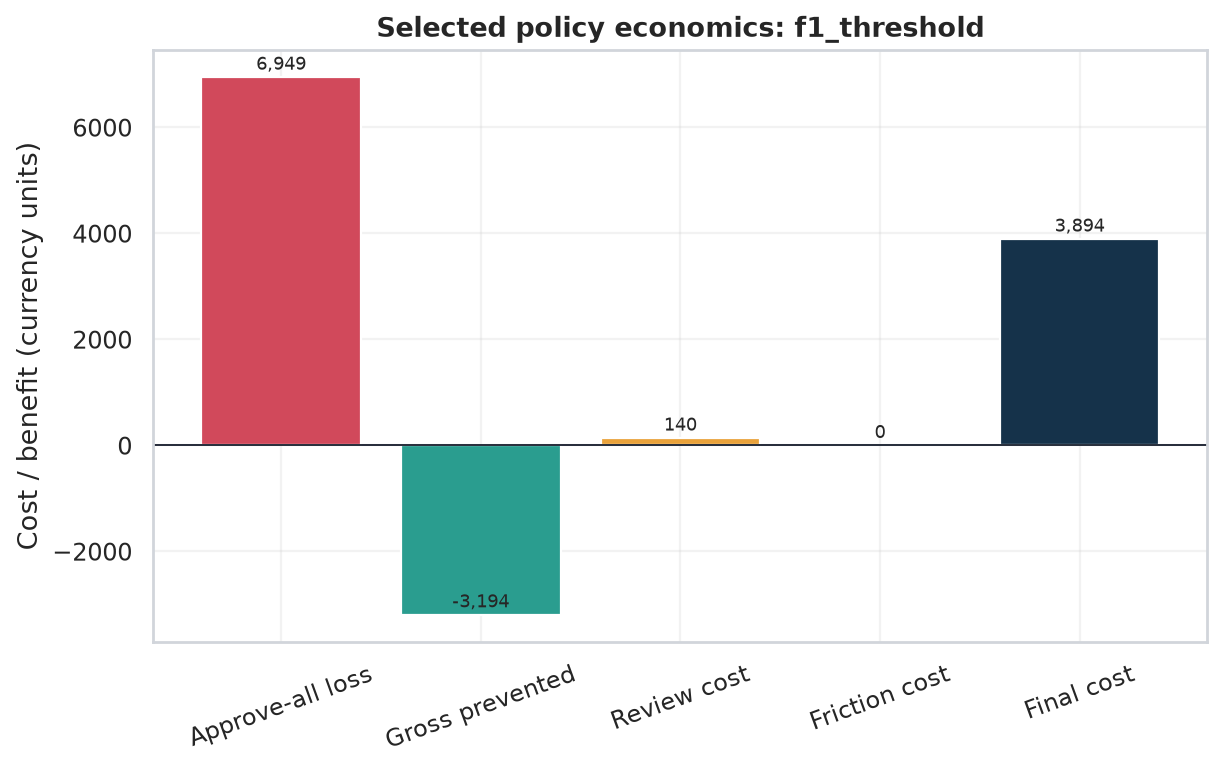

In [5]:
display(Image(filename=str(FIG / '06_business_waterfall.png')))

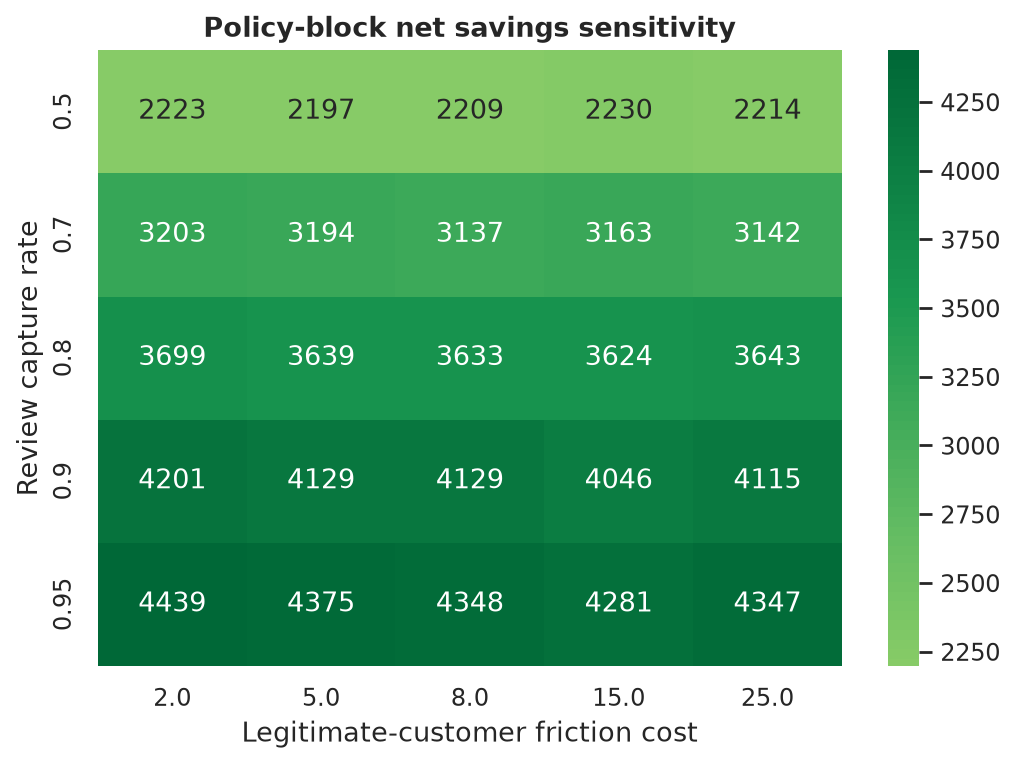

In [6]:
display(Image(filename=str(FIG / '07_sensitivity_heatmap.png')))